# Profiling et Visualisation (SegmentIQ)
Ce notebook utilise le modèle entraîné pour analyser les données et afficher les graphiques (PCA, Distribution, Feature Importance).

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import joblib

from src.config.config import DATA_PATH, MODEL_PATH
from src.cleaning.cleaning import nettoyage
from src.preprocessing.preprocessing import log1p, standarisation
from src.non_supervised.pca import apply_pca
from src.utils.visualisation import (
    plot_clusters_pca, 
    plot_cluster_distribution, 
    plot_feature_importance
)

### 1. Chargement des données et du modèle

In [3]:
data = pd.read_excel(DATA_PATH)
data_rfm = nettoyage(data)

model_data = joblib.load(MODEL_PATH)
model = model_data['model']
noms_clusters = model_data['noms_clusters']

rfm_model = data_rfm[['Recency', 'Frequency', 'Monetary']].copy()
log1p(rfm_model)

data_rfm['Nom_Cluster'] = model.predict(rfm_model)
data_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Nom_Cluster
0,12346.0,325,1,77183.60,Clients Inactifs
1,12347.0,1,7,4310.00,Clients Premium
2,12348.0,74,4,1797.24,Clients Inactifs
3,12349.0,18,1,1757.55,Clients Inactifs
4,12350.0,309,1,334.40,Clients Réguliers


### 2. Distribution des Clusters

c:\Users\Youcode\Desktop\SegmentIQ\src\utils\visualisation.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


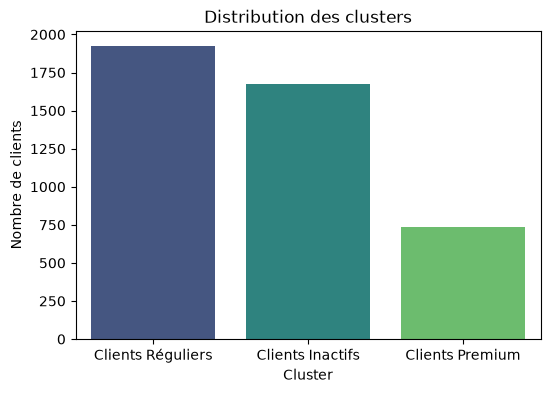

In [4]:
cluster_counts = data_rfm['Nom_Cluster'].value_counts()
plot_cluster_distribution(cluster_counts)

### 3. Visualisation PCA (Analyse en Composantes Principales)

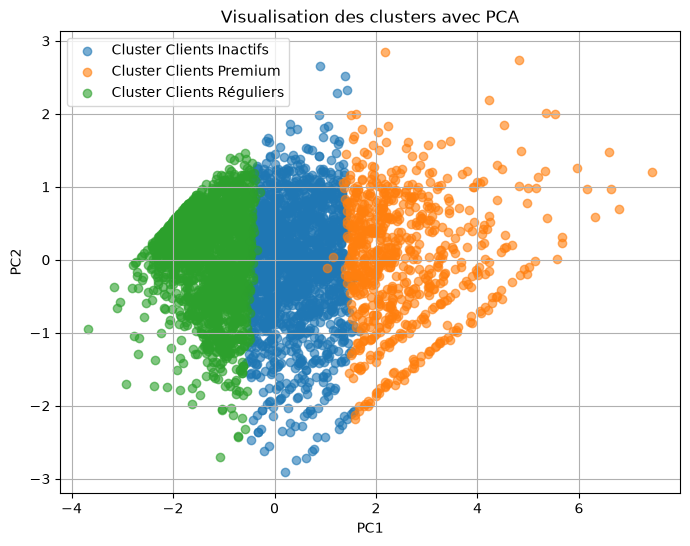

In [5]:
data_scaled = standarisation(rfm_model)
pca, X_pca = apply_pca(data_scaled, n_components=2)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = data_rfm['Nom_Cluster'].values


plot_clusters_pca(pca_df)

### 4. Importance des Features (Random Forest)

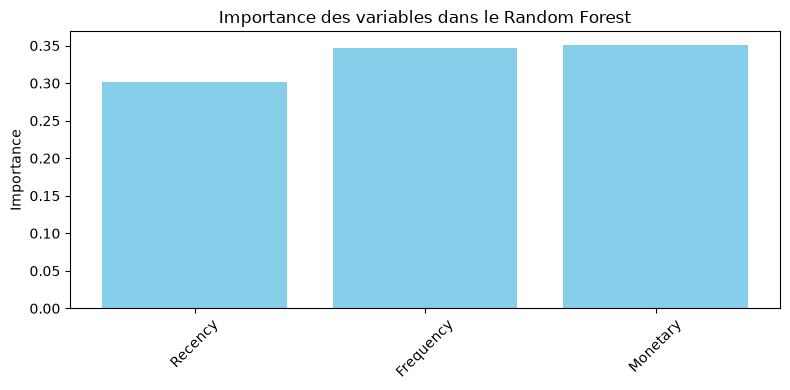

In [6]:
feature_names = ['Recency', 'Frequency', 'Monetary']
plot_feature_importance(feature_names, model.feature_importances_)